In [1]:
%cd ../

/Users/paulb/Desktop/code/research/babi


In [ ]:
import os
import pandas as pd
import numpy as np
import data.constants
from data import plotting
import models.constants
import data.prepare.constants
from models import processing
import matplotlib.pyplot as plt

import importlib
importlib.reload(data.constants)
importlib.reload(models.constants)
importlib.reload(plotting)
importlib.reload(processing)

<module 'models.processing' from '/Users/paulb/Desktop/code/research/babi/models/processing.py'>

In [3]:
(train_x, train_y), val, normative_test, abnormal_test, (g_min, g_max) = processing.get_training_dataset()
print(f"Training dataset shape: {train_x.shape}, Validation dataset shape: {val.shape}, Test dataset shape: {normative_test.shape}, Abnormal test dataset shape: {abnormal_test.shape}")

Training dataset shape: (1296, 20, 1), Validation dataset shape: (162, 20, 1), Test dataset shape: (162, 20, 1), Abnormal test dataset shape: (181, 20, 1)


Epoch 1/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1562 - val_loss: 0.0323
Epoch 2/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0218 - val_loss: 0.0117
Epoch 3/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0121 - val_loss: 0.0083
Epoch 4/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0083 - val_loss: 0.0063
Epoch 5/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0065 - val_loss: 0.0059
Epoch 6/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0056 - val_loss: 0.0049
Epoch 7/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0049 - val_loss: 0.0041
Epoch 8/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0042 - val_loss: 0.0034
Epoch 9/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0035 - val_loss: 0.0028
Epoch 10/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0029 - val_loss: 0.0024
Epoch 11/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0025 - val_loss: 0.0020
Epoch 12/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0

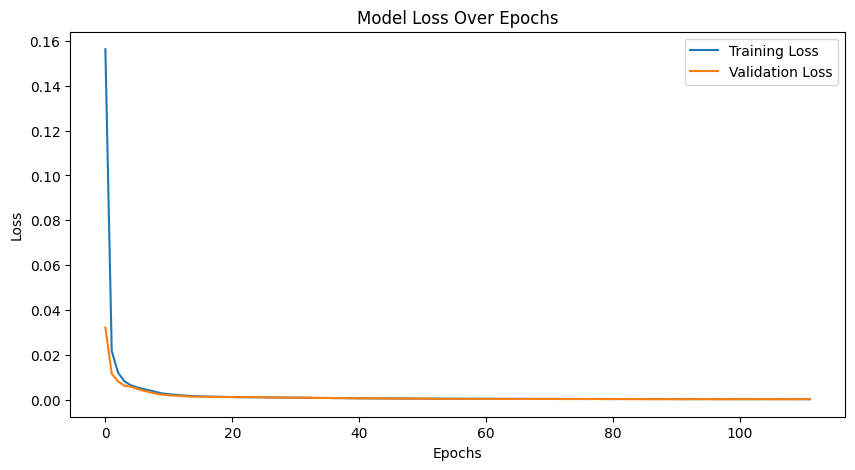

In [4]:
from models import autoencoder
from keras.callbacks import EarlyStopping, ModelCheckpoint

ae = autoencoder.build()

history = ae.fit(
    train_x, train_y,
    validation_data=(val, val),
    epochs=200,
    batch_size=32,
    shuffle=True,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ModelCheckpoint('models/out/model.keras', monitor='val_loss', save_best_only=True)
    ]
)

# plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [5]:
sample_path = os.listdir(os.path.join(data.constants.preprocessed_data_dir, "capnostream"))[1]
sample: pd.DataFrame = pd.read_pickle(os.path.join(data.constants.preprocessed_data_dir, "capnostream", sample_path))
print(sample.attrs)
signal = processing.scale_sample(sample["co2_wave"].to_numpy(), g_min, g_max)

{'Patient ID': 'BB_003_1', 'Patient Type': 'Infant/Neonatal', 'Report Generation Time': 'Mar 10,25  08:12:56 AM', 'Date': 'Mar 10,25'}


In [6]:
from models.processing import augmentation
from numpy.lib.stride_tricks import sliding_window_view
from data.prepare import constants

units = sliding_window_view(signal, (constants.unit_length, ))
units = np.array([augmentation.stretch_to_unit_length(unit)[0] for unit in units])

In [7]:
threshold = autoencoder.calculate_threshold(ae, val, percentile=96)
print(f"Calculated threshold: {threshold}")
predict = autoencoder.predictor(ae, threshold)
batch_predict = autoencoder.batch_predictor(ae, threshold)

Calculated threshold: 0.0008241867179709808


In [8]:
from itertools import compress
from time import perf_counter

start = perf_counter()
recons, errors, labels = batch_predict(units)
elapsed = perf_counter() - start

print(f"batch_predict took {elapsed:.4f} s ({len(units)/elapsed:.2f} units/s)")
predictions: list[tuple[np.ndarray, np.ndarray, np.floating, np.bool]] = list(zip(units, recons, errors, labels))
valid_predictions = list(compress(predictions, labels))
invalid_predictions = list(compress(predictions, ~labels))

print(f"Total units: {len(predictions)}")
print(f"Valid units: {len(valid_predictions)} ({round(len(valid_predictions) / len(predictions) * 100, 2)}%)")
print(f"Invalid units: {len(invalid_predictions)} ({round(len(invalid_predictions) / len(predictions) * 100, 2)}%)")

batch_predict took 0.6783 s (59541.60 units/s)
Total units: 40386
Valid units: 2088 (5.17%)
Invalid units: 38298 (94.83%)


In [ ]:
# statistics!

# mean validation reconstruction error
val_reconstructions = ae.predict(val, verbose='silent')
mean_val_recon_error = np.mean(np.mean(np.power(val - val_reconstructions, 2), axis=1))
print(f"Mean reconstruction error on validation set: {mean_val_recon_error}")

# normative unit accuracy and mean reconstruction error
normative_recons, normative_errors, normative_labels = batch_predict(normative_test.reshape(-1, data.prepare.constants.unit_length))
normative_accuracy = round(np.sum(normative_labels) / len(normative_labels), 2)
mean_normative_recon_error = np.mean(normative_errors)
print(f"Normative unit accuracy: {normative_accuracy * 100}%, Mean reconstruction error: {mean_normative_recon_error}")

# abnormal unit accuracy and mean reconstruction error
abnormal_recons, abnormal_errors, abnormal_labels = batch_predict(abnormal_test.reshape(-1, data.prepare.constants.unit_length) )
abnormal_accuracy = round(np.sum(~abnormal_labels) / len(abnormal_labels), 2)
mean_abnormal_recon_error = np.mean(abnormal_errors)
print(f"Abnormal unit accuracy: {abnormal_accuracy * 100}%, Mean reconstruction error: {mean_abnormal_recon_error}")

Mean reconstruction error on validation set: 0.00031970527748340685
Normative unit accuracy: 90.0%, Mean reconstruction error: 0.00036947771847553
Abnormal unit accuracy: 100.0%, Mean reconstruction error: 0.03361793628402903



----- VALID SAMPLES -----

(20,) (20,) 0.0007549247032812269 True
Valid Sample 1 (Index 213) | 0.000755 (-6.9e-05)


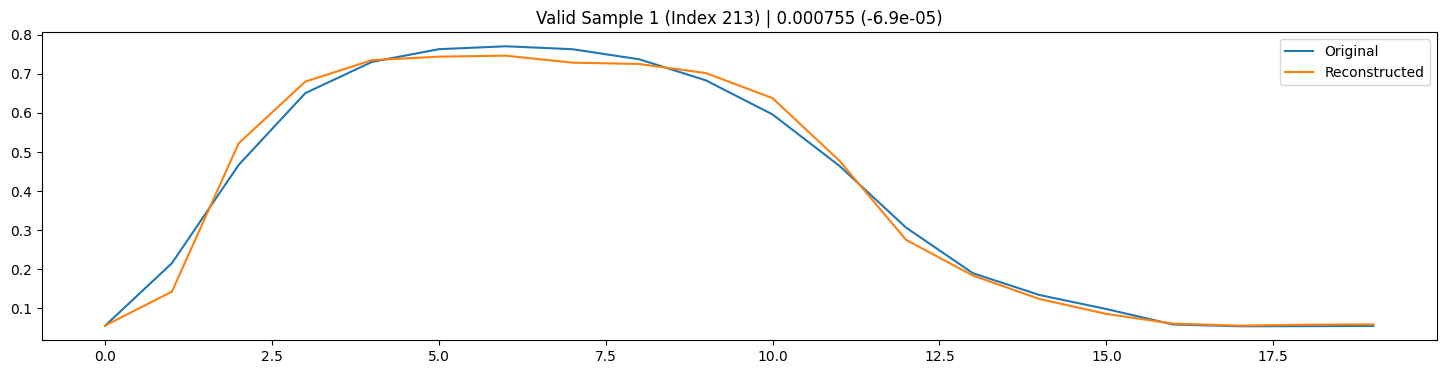

(20,) (20,) 0.00041934455705245813 True
Valid Sample 2 (Index 1265) | 0.000419 (-0.000405)


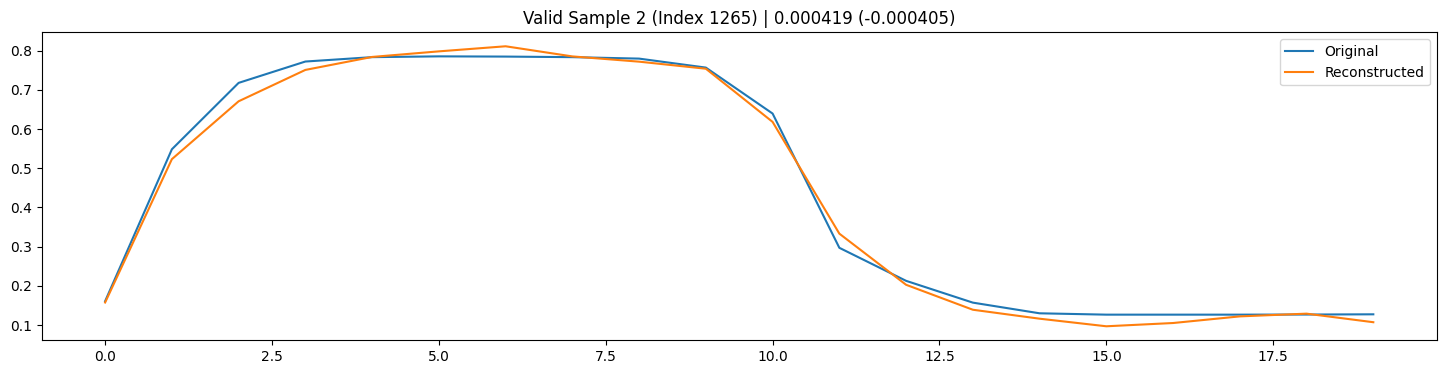

(20,) (20,) 0.00045087111089897196 True
Valid Sample 3 (Index 1128) | 0.000451 (-0.000373)


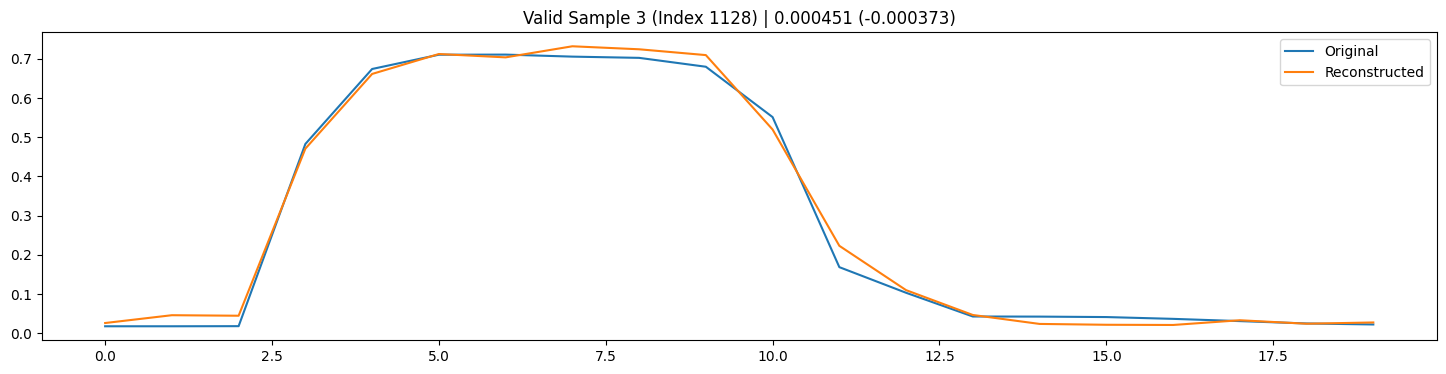


-----INVALID SAMPLES -----

Invalid Sample 1 (Index 10905) | 0.002016 (0.001192)


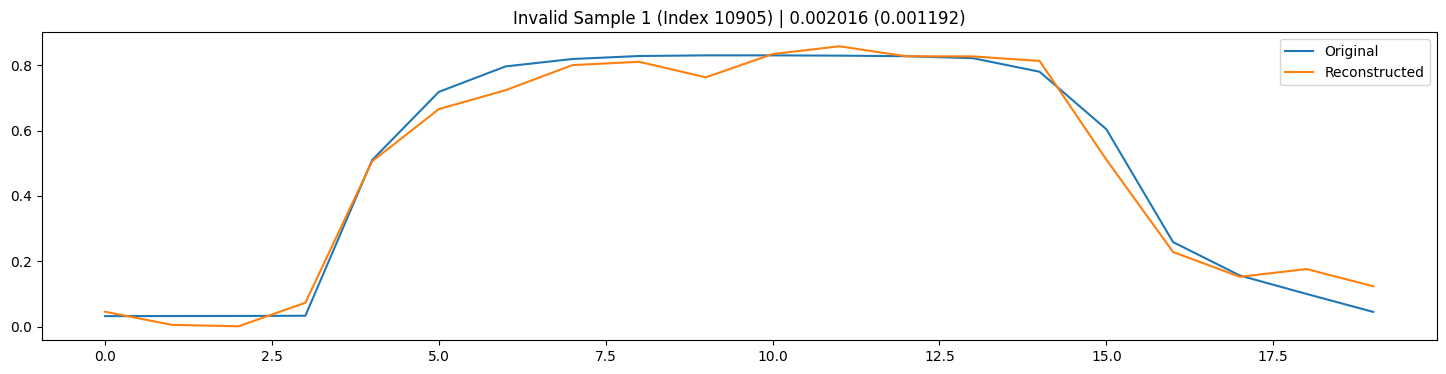

Invalid Sample 2 (Index 28350) | 0.057373 (0.056549)


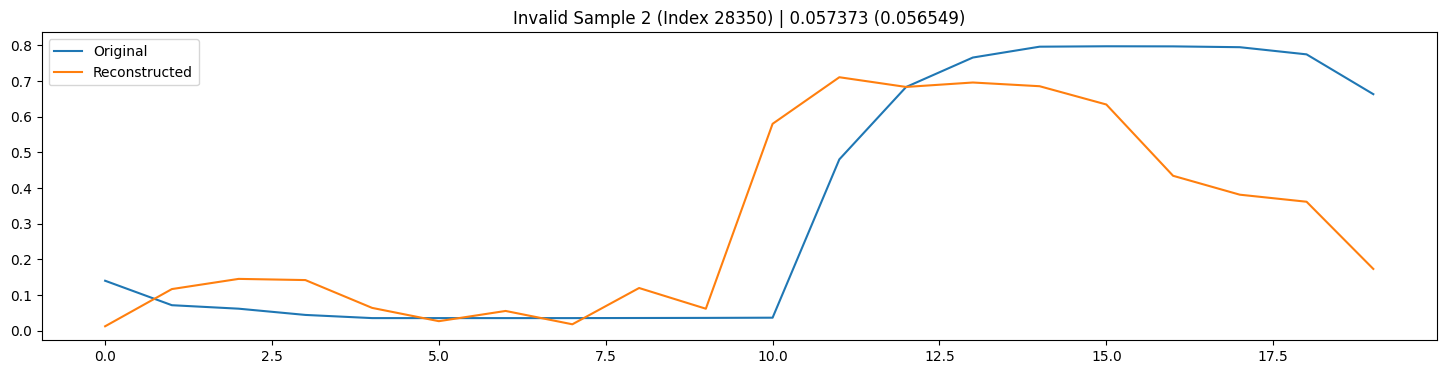

Invalid Sample 3 (Index 15439) | 0.018126 (0.017302)


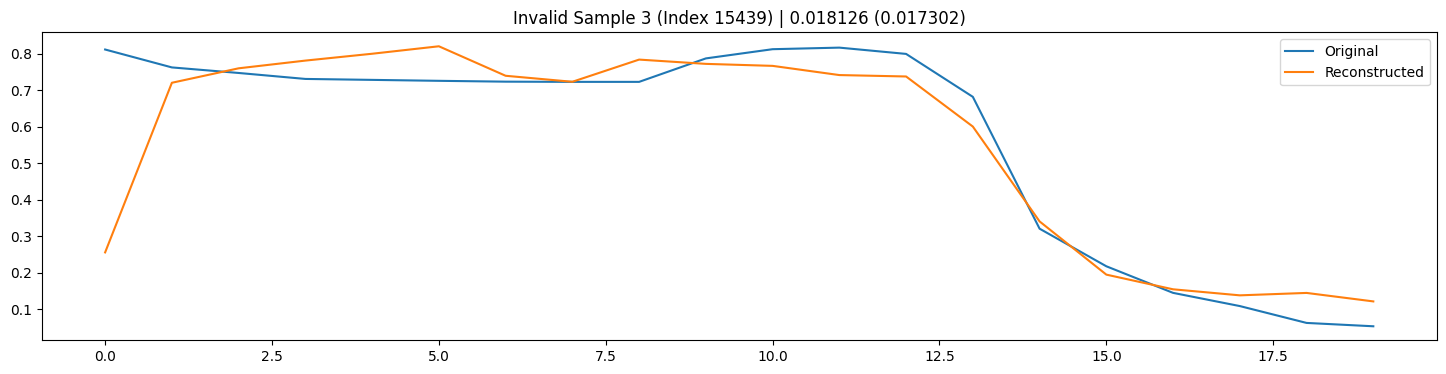

In [10]:
print("\n----- VALID SAMPLES -----\n")

n_valid_predictions = 3
for i in range(n_valid_predictions):
    index = np.random.randint(0, len(valid_predictions))
    original, recon, error, valid = valid_predictions[index]
    print(original.shape, recon.shape, error, valid)
    title = f'Valid Sample {i+1} (Index {index}) | {round(error, 6)} ({round(error - threshold, 6)})'
    print(title)
    plotting.dual(original, recon, title=title)

print("\n-----INVALID SAMPLES -----\n")

n_invalid_predictions = 3
for i in range(n_invalid_predictions):
    index = np.random.randint(0, len(invalid_predictions))
    original, recon, error, valid = invalid_predictions[index]
    title = f'Invalid Sample {i+1} (Index {index}) | {round(error, 6)} ({round(error - threshold, 6)})'
    print(title)
    plotting.dual(original, recon, title=title)

----- BEST VALID SAMPLES -----

Valid Sample 1 | 7.4e-05 (-0.00075)


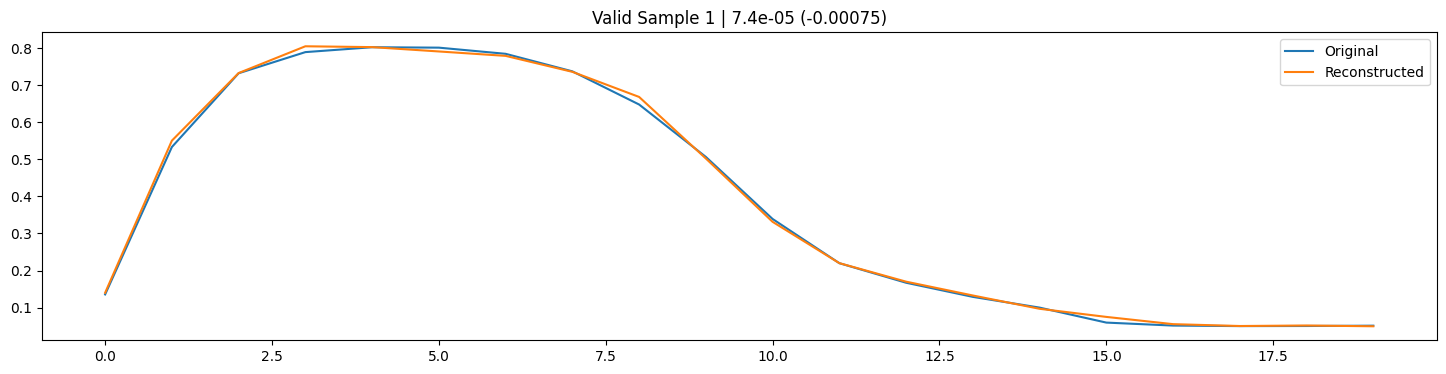

Valid Sample 2 | 8.5e-05 (-0.000739)


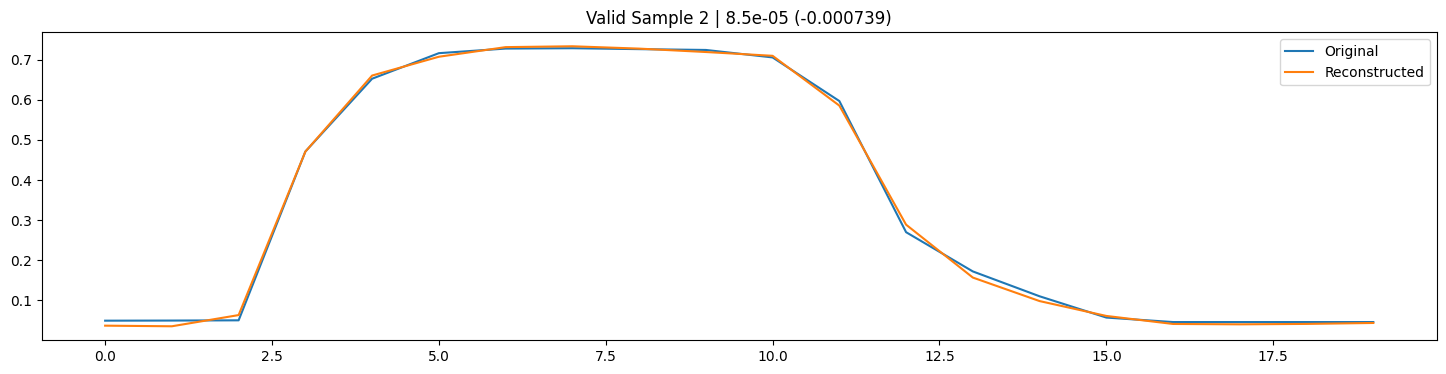

Valid Sample 3 | 9.2e-05 (-0.000733)


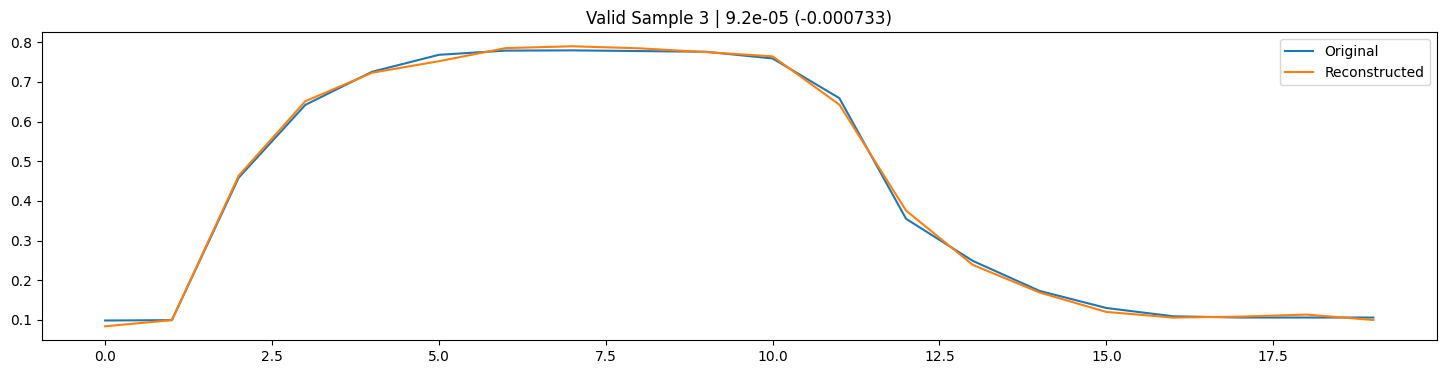


----- WORST VALID SAMPLES -----

Valid Sample 1 | 0.000824 (-0.0)


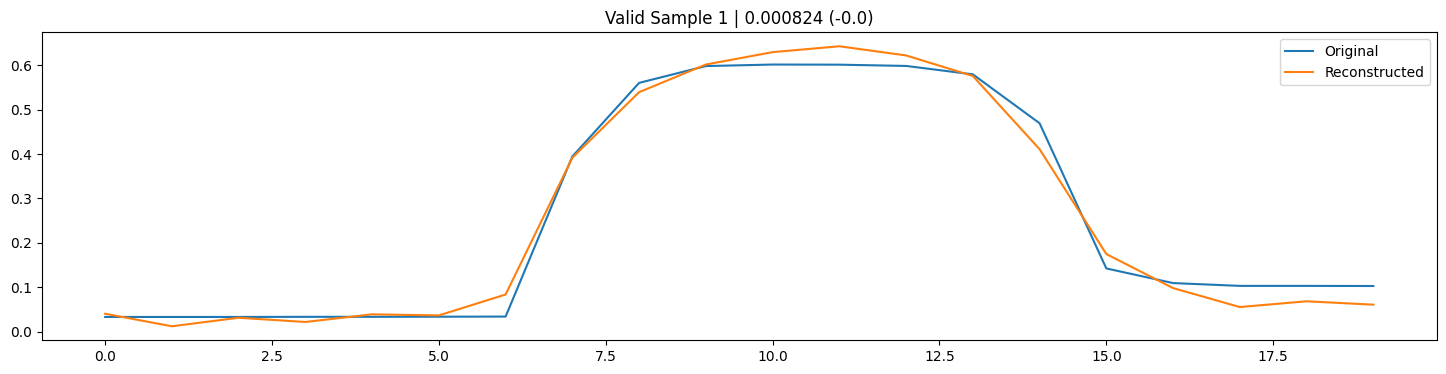

Valid Sample 2 | 0.000824 (-0.0)


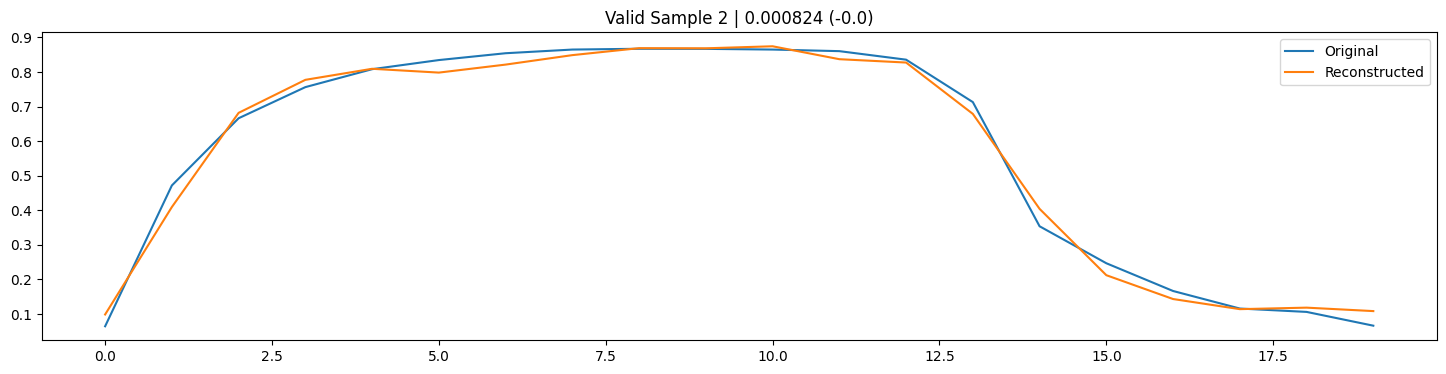

Valid Sample 3 | 0.000823 (-1e-06)


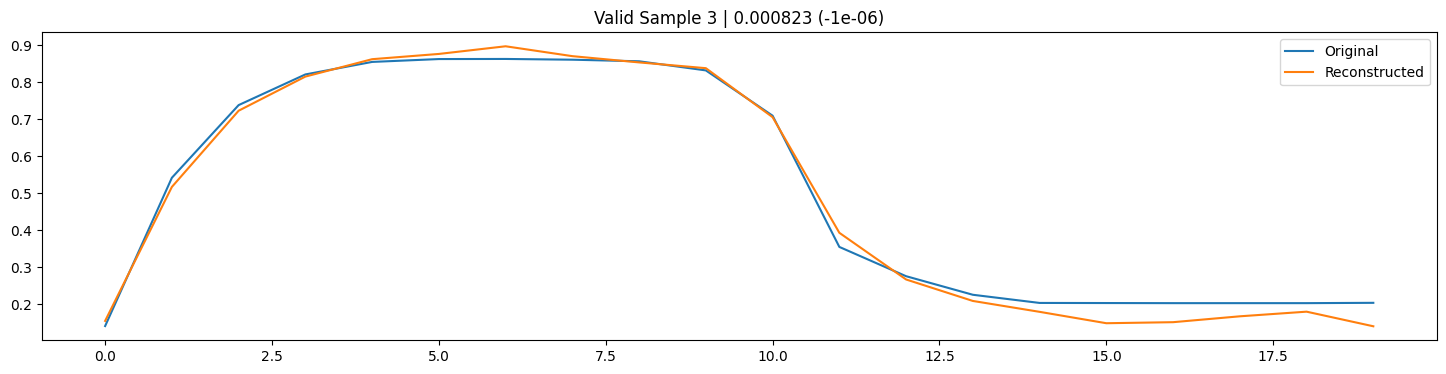

In [11]:
print("----- BEST VALID SAMPLES -----\n")

n_best_valid = 3
best_valid = sorted(valid_predictions, key=lambda x: x[2])
for i in range(n_best_valid):
    original, recon, error, valid = best_valid[i]
    title = f'Valid Sample {i+1} | {round(error, 6)} ({round(error - threshold, 6)})'
    print(title)
    plotting.dual(original, recon, title=title)

print("\n----- WORST VALID SAMPLES -----\n")

n_worst_valid = 3
worst_valid = sorted(valid_predictions, key=lambda x: x[2], reverse=True)
for i in range(n_worst_valid):
    original, recon, error, valid = worst_valid[i]
    title = f'Valid Sample {i+1} | {round(error, 6)} ({round(error - threshold, 6)})'
    print(title)
    plotting.dual(original, recon, title=title)
